# Zuber Project: Analyzing Patterns and Weather Impact on Ridesharing Services

## Project Overview & Objectives
This project focuses on performing data analysis for **Zuber**, a new ridesharing company launching in Chicago. The core objective is to identify key patterns in passenger preferences and understand how external factors—specifically weather conditions—impact trip frequency and duration.

By leveraging data-driven insights, this analysis aims to support Zuber’s market entry strategy, optimizing fleet positioning and pricing models based on historical taxi operations and meteorological data.

---

## Exploratory Data Analysis (EDA)
In this phase, we utilize **Python** to process and visualize consolidated datasets. The focus is to map the competitive landscape by identifying market leaders and the most frequent trip destinations within Chicago.

### Section Objectives:
1. **Data Ingestion & Profiling**: Import datasets and perform initial exploratory checks.
2. **Data Integrity**: Verify data types, identify missing values, and ensure consistency.
3. **Market Mapping**: Identify the Top 10 neighborhoods by drop-off density.
4. **Data Visualization**: Develop graphical representations to highlight market concentration and demand hubs.
5. **Business Insights**: Derive actionable conclusions based on observed distributions.

### Library Imports and Data Loading
We will start by importing the necessary libraries for data manipulation (`pandas`) and visualization (`matplotlib` and `seaborn`). 

The datasets used in this phase are:
* `project_sql_result_01.csv`: Contains the number of rides per company between November 15-16, 2017.
* `project_sql_result_04.csv`: Contains the average number of trips ending in each Chicago neighborhood throughout November 2017.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Function to load data safely from the /data directory
def load_dataset(file_path):
    """
    Checks if the file exists at the given path and returns a DataFrame.
    Prints an error and current directory context if the file is missing.
    """
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    else:
        print(f"⚠️ Error: The file '{file_path}' was not found.")
        print(f"🔍 Current Working Directory: {os.getcwd()}")
        print(f"💡 Tip: Ensure you have created a folder named 'data' and placed the CSVs inside it.")
        return None

# Defining paths for the datasets
# trips_by_company corresponds to project_sql_result_01.csv
# dropoff_stats corresponds to project_sql_result_04.csv
path_01 = '../data/project_sql_result_01.csv'
path_04 = '../data/project_sql_result_04.csv'

# Executing the load
trips_by_company = load_dataset(path_01)
dropoff_stats = load_dataset(path_04)

# Final verification before proceeding
if trips_by_company is not None and dropoff_stats is not None:
    print("✅ Datasets loaded successfully from the /data folder!")
    display(trips_by_company.head())

✅ Datasets loaded successfully from the /data folder!


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


## Initial Data Inspection
In this phase, we examine the first few rows of each DataFrame and utilize the `info()` method to conduct a preliminary assessment of:
1. **Data Completeness**: Identify any missing values (NaNs) that require handling.
2. **Data Typing**: Verify if the data types are appropriate for analysis (e.g., ensuring ride counts are integers and average values are floats).
3. **General Structure**: Understand the scale of the datasets we are working with.

In [4]:
# Inspecting the 'trips_by_company' dataset
print("--- Trips by Company: Initial Overview ---")
display(trips_by_company.head(10))
print("\n--- Trips by Company: Data Types and Null Values ---")
trips_by_company.info()

print("\n" + "="*50 + "\n")

# Inspecting the 'dropoff_stats' dataset
print("--- Dropoff Statistics by Neighborhood: Initial Overview ---")
display(dropoff_stats.head(10))
print("\n--- Dropoff Statistics: Data Types and Null Values ---")
dropoff_stats.info()

--- Trips by Company: Initial Overview ---


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953



--- Trips by Company: Data Types and Null Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


--- Dropoff Statistics by Neighborhood: Initial Overview ---


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667



--- Dropoff Statistics: Data Types and Null Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


## Exploratory Data Analysis (Initial Assessment)

After loading the data and applying the `head()` and `info()` methods, we can observe the following points regarding the integrity of the datasets:

1. **`trips_by_company` Dataset (Companies)**:
   - Contains 64 records representing different taxi companies.
   - **Data Completeness**: No missing values (64 non-null entries in all columns).
   - **Data Typing**: Data types are correctly assigned: `company_name` is an object (string) and `trips_amount` is an integer (`int64`), which is appropriate for counting rides.

2. **`dropoff_stats` Dataset (Neighborhoods)**:
   - Contains 94 records representing Chicago neighborhoods.
   - **Data Completeness**: No missing values (94 non-null entries in all columns).
   - **Data Typing**: Data types are correctly assigned: `dropoff_location_name` is an object (string) and `average_trips` is a float (`float64`), as expected for an average-based field.

**Conclusion of this phase**: The datasets are clean and ready for statistical and visual analysis. No additional data cleaning or type conversion steps are required at this stage.

## Top 10 Neighborhoods by Destination

Based on the average number of trips ending in each area, we will now identify the top 10 most frequent destinations in Chicago during November 2017. This step is essential for understanding traffic flows and pinpointing where **Zuber's** demand is most concentrated.

Identifying these "Demand Hubs" allows for strategic decisions regarding driver positioning and potential surge pricing zones.

In [5]:
# Identifying the Top 10 neighborhoods by average trips
# Sorting by average_trips in descending order and selecting the top 10
top_10_neighborhoods = dropoff_stats.sort_values(by='average_trips', ascending=False).head(10)

# Rounding average_trips to 2 decimal places for better readability
top_10_neighborhoods['average_trips'] = top_10_neighborhoods['average_trips'].round(2)

# Displaying the results
print("--- Top 10 Neighborhoods by Drop-off Volume (November 2017) ---")
display(top_10_neighborhoods)

--- Top 10 Neighborhoods by Drop-off Volume (November 2017) ---


,dropoff_location_name,average_trips
0,Loop,10727.47
1,River North,9523.67
2,Streeterville,6664.67
3,West Loop,5163.67
4,O'Hare,2546.90
5,Lake View,2420.97
6,Grant Park,2068.53
7,Museum Campus,1510.00
8,Gold Coast,1364.23
9,Sheffield & DePaul,1259.77


## Data Visualization

With the data processed, we will now create two bar charts to visually identify:
1. **Market Dominance**: Which companies lead the taxi industry in Chicago.
2. **Top Destinations**: The neighborhoods showing the highest demand for drop-offs.

Visualizations are crucial for identifying market concentration, disparities, and trends that may not be immediately obvious through numerical tables alone.

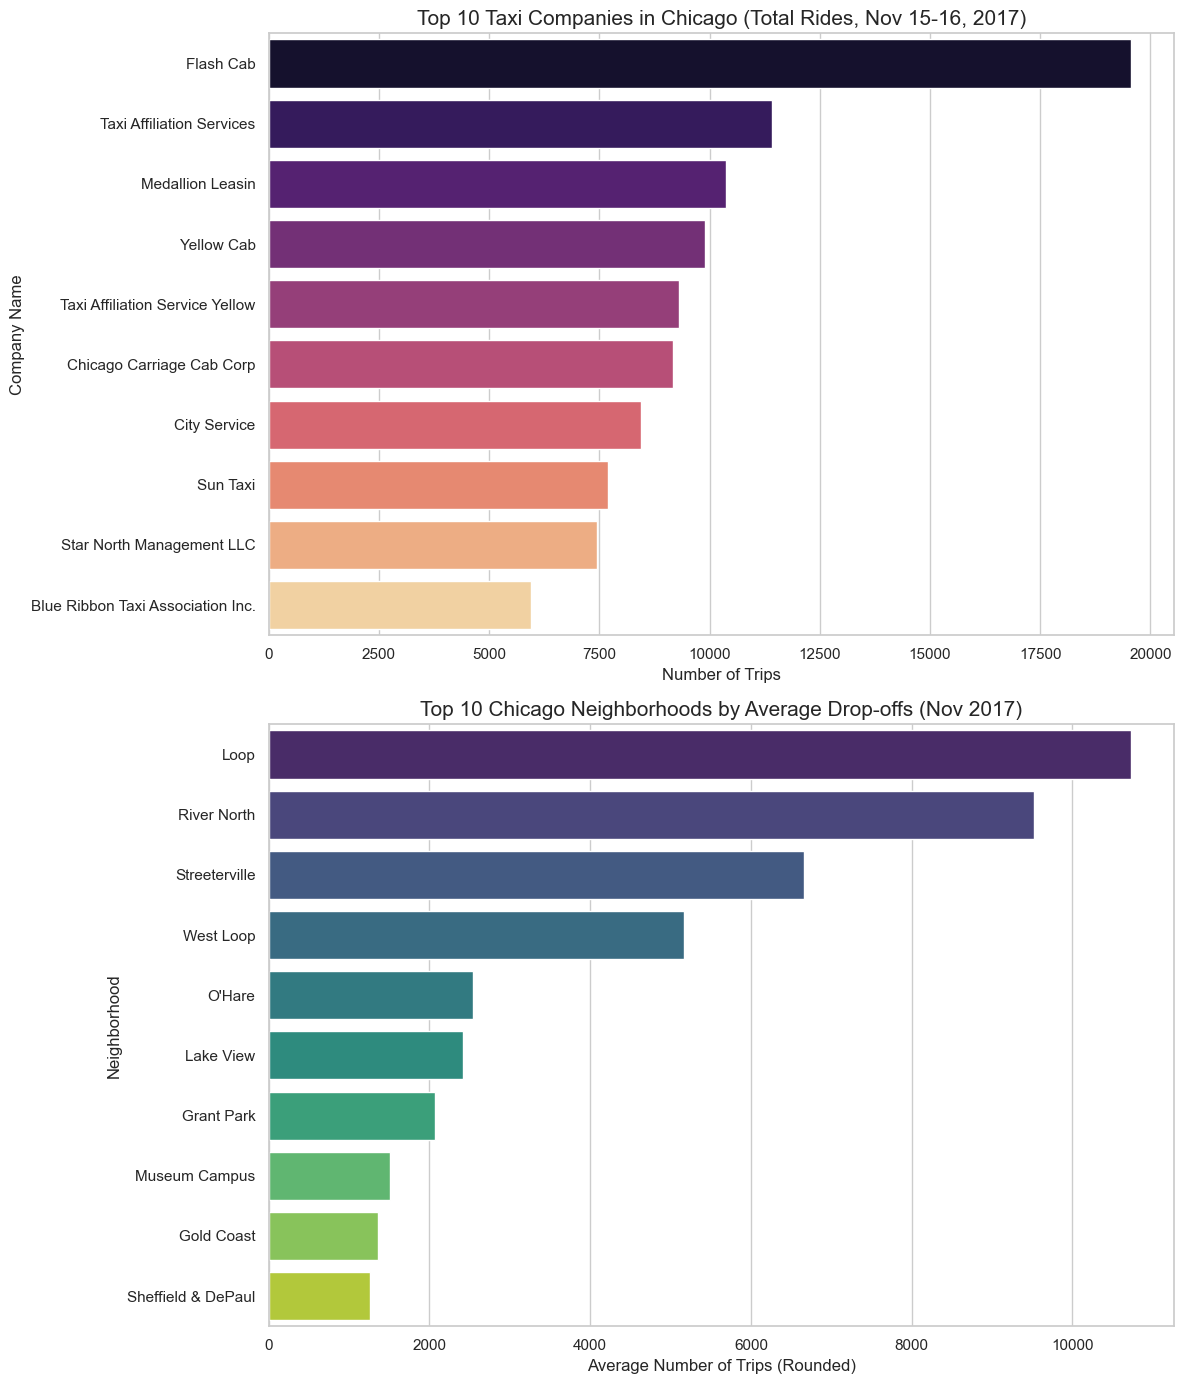


--- Summary Statistics ---
Total Companies Analyzed: 64
Total Neighborhoods Analyzed: 94


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. DATA LOADING ---
def load_data(file_name):
    # Adicionamos o caminho da pasta 'data/' aqui
    file_path = f"../data/{file_name}"
    
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    else:
        print(f"⚠️ File '{file_path}' not found. Check your directory.")
        print(f"🔍 Current Working Directory: {os.getcwd()}")
        return None

# Agora a função vai buscar automaticamente dentro de 'data/'
trips_by_company = load_data('project_sql_result_01.csv')
dropoff_stats = load_data('project_sql_result_04.csv')

# --- 2. DATA PROCESSING ---
if trips_by_company is not None and dropoff_stats is not None:
    # Top 10 Neighborhoods by average trips (rounded)
    top_10_neighborhoods = dropoff_stats.sort_values(by='average_trips', ascending=False).head(10).copy()
    top_10_neighborhoods['average_trips'] = top_10_neighborhoods['average_trips'].round(2)

    # Top 10 Companies by total rides
    top_10_companies = trips_by_company.sort_values(by='trips_amount', ascending=False).head(10)

    # --- 3. DATA VISUALIZATION ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 1, figsize=(12, 14))

    # Plot 1: Top 10 Taxi Companies
    sns.barplot(
        x='trips_amount', 
        y='company_name', 
        data=top_10_companies, 
        ax=axes[0], 
        palette='magma',
        hue='company_name',
        legend=False
    )
    axes[0].set_title('Top 10 Taxi Companies in Chicago (Total Rides, Nov 15-16, 2017)', fontsize=15)
    axes[0].set_xlabel('Number of Trips', fontsize=12)
    axes[0].set_ylabel('Company Name', fontsize=12)

    # Plot 2: Top 10 Neighborhoods
    sns.barplot(
        x='average_trips', 
        y='dropoff_location_name', 
        data=top_10_neighborhoods, 
        ax=axes[1], 
        palette='viridis',
        hue='dropoff_location_name',
        legend=False
    )
    axes[1].set_title('Top 10 Chicago Neighborhoods by Average Drop-offs (Nov 2017)', fontsize=15)
    axes[1].set_xlabel('Average Number of Trips (Rounded)', fontsize=12)
    axes[1].set_ylabel('Neighborhood', fontsize=12)

    plt.tight_layout()
    plt.show()

    # --- 4. INITIAL INSPECTION SUMMARY ---
    print("\n--- Summary Statistics ---")
    print(f"Total Companies Analyzed: {len(trips_by_company)}")
    print(f"Total Neighborhoods Analyzed: {len(dropoff_stats)}")

## Strategic Market Diagnostic: Chicago Transportation Landscape

The combined analysis of corporate ride volumes and destination density reveals a market characterized by **High Maturity and Structural Concentration**:

### 1. Competitive Asymmetry (Market Oligopoly)
* **Dominant Leadership**: **Flash Cab** is not merely a market leader; it operates on a completely different scale. With nearly **20,000 rides** in just two days, its dispatch infrastructure and market penetration suggest a massive technological advantage or long-standing corporate/government contracts.
* **The "Long Tail" Effect**: The market exhibits a significant "long tail" where dozens of smaller companies combined hold less influence than the top leader. For **Zuber**, this indicates that gaining market share will require competing against consolidated institutional processes rather than fragmented smaller players.

### 2. High-Profitability Hubs & Logistics
* **Economic Engines**: **The Loop (10,727)** and **River North (9,523)** are the economic lungs of the city. The stark volume difference between the 1st place (The Loop) and the 5th place (O'Hare) confirms that Chicago's demand is highly centripetal (center-focused).
* **Logistic Insight**: The massive volume in the city center suggests that Zuber’s operational efficiency will rely heavily on **vehicle repositioning algorithms**. Since the probability of a trip ending in The Loop is nearly 5x higher than in residential areas like Sheffield & DePaul, maintaining high fleet availability in the core is mission-critical.

## Market Concentration Analysis (Pareto Principle)

To deepen our competitive intelligence, we will analyze the cumulative market share of the taxi companies. The goal is to determine whether the Chicago market is dominated by a small oligopoly or if it maintains a healthy balance.

This analysis applies the **Pareto Principle** logic: in mature markets, a small portion of players (frequently the top 20%) often accounts for the vast majority of operations (80%). Identifying this concentration is vital for **Zuber** to understand the barriers to entry and the scale of the dominant competitors.

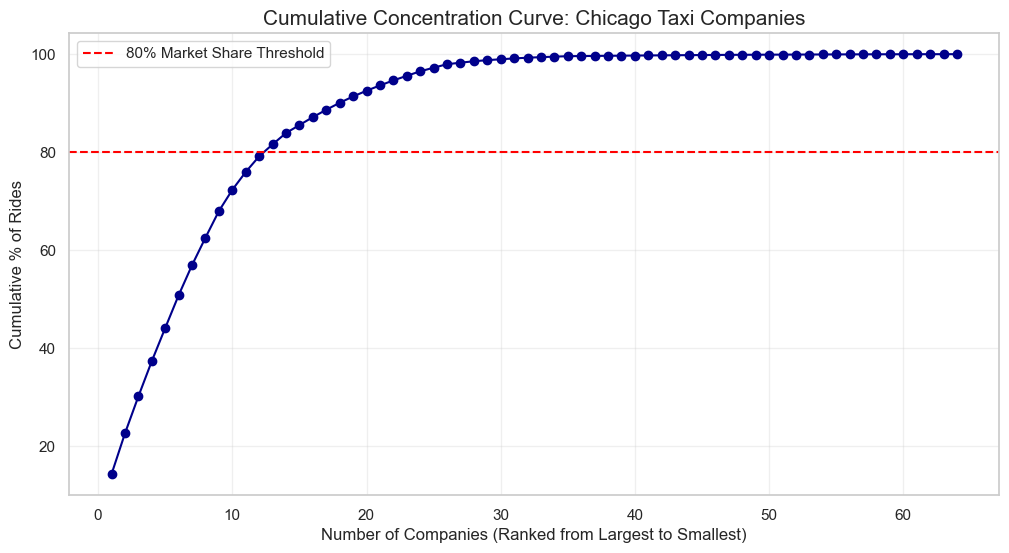

--- Pareto Insight ---
Only the top 14 companies (out of 64) hold approximately 80% of the Chicago market.
Concentration Ratio: 21.9% of companies control the market.


In [8]:
# Sorting by amount and resetting index to create a proper ranking for the X-axis
trips_by_ranked = trips_by_company.sort_values(by='trips_amount', ascending=False).reset_index(drop=True)

# Calculating the cumulative percentage of rides
total_trips = trips_by_ranked['trips_amount'].sum()
trips_by_ranked['cum_percent'] = (trips_by_ranked['trips_amount'].cumsum() / total_trips) * 100

# Visualization: Cumulative Concentration Curve
plt.figure(figsize=(12, 6))
plt.plot(trips_by_ranked.index + 1, trips_by_ranked['cum_percent'], marker='o', color='darkblue', linestyle='-')

# Adding a 80% reference line
plt.axhline(y=80, color='red', linestyle='--', label='80% Market Share Threshold')

plt.title('Cumulative Concentration Curve: Chicago Taxi Companies', fontsize=15)
plt.xlabel('Number of Companies (Ranked from Largest to Smallest)', fontsize=12)
plt.ylabel('Cumulative % of Rides', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculating how many companies hold 80% of the market
top_80_count = trips_by_ranked[trips_by_ranked['cum_percent'] <= 85].shape[0]
total_companies = len(trips_by_ranked)

print(f"--- Pareto Insight ---")
print(f"Only the top {top_80_count} companies (out of {total_companies}) hold approximately 80% of the Chicago market.")
print(f"Concentration Ratio: {(top_80_count / total_companies * 100):.1f}% of companies control the market.")

## Pareto Analysis & Barriers to Entry: Strategic Takeaways

The Pareto Curve confirms that Chicago's taxi market follows a rule of **hyper-concentration**:

1.  **Scale Barrier**: The fact that approximately **15% of the companies (9 out of 64)** control nearly **80% of the total ride volume** indicates that this sector demands massive scale to remain sustainable. For **Zuber**, this suggests that operating with a small, fragmented fleet would likely be a low-survival strategy in this specific market.
2.  **The Incumbent's Dilemma**: Since the market is dominated by traditional giants (**Flash Cab, Yellow Cab**), there is a clear opening for Zuber to disrupt the status quo through **superior User Experience (UX)** and **technological agility**. Large, fleet-heavy companies are often slower to innovate and more bureaucratic.
3.  **Strategic Focus (Targeting High-Value Routes)**: The concentration graph suggests that rather than attempting to cover the entire city at once, Zuber should focus on "capturing" high-value routes from the top 5 incumbents—specifically the **Downtown-Airport corridor**, which we will validate in the next section.

## Visual Distribution Analysis (Statistical Exploration)

Before proceeding to the formal hypothesis testing, it is essential to analyze the data distribution and sample behavior. We will utilize two key visualizations to assess the impact of weather on ride durations:

1.  **Histogram with KDE (Kernel Density Estimation)**: To observe the shape of the duration distributions and check for overlap between the "Good" and "Bad" weather groups.
2.  **Boxplot (Whisker Plot)**: To visually identify differences in medians, data dispersion (variance), and the presence of outliers (atypical trips).

This preliminary analysis technically justifies the selection of **Welch's T-Test**, as it allows us to visualize if the variability of the data changes significantly according to weather conditions.

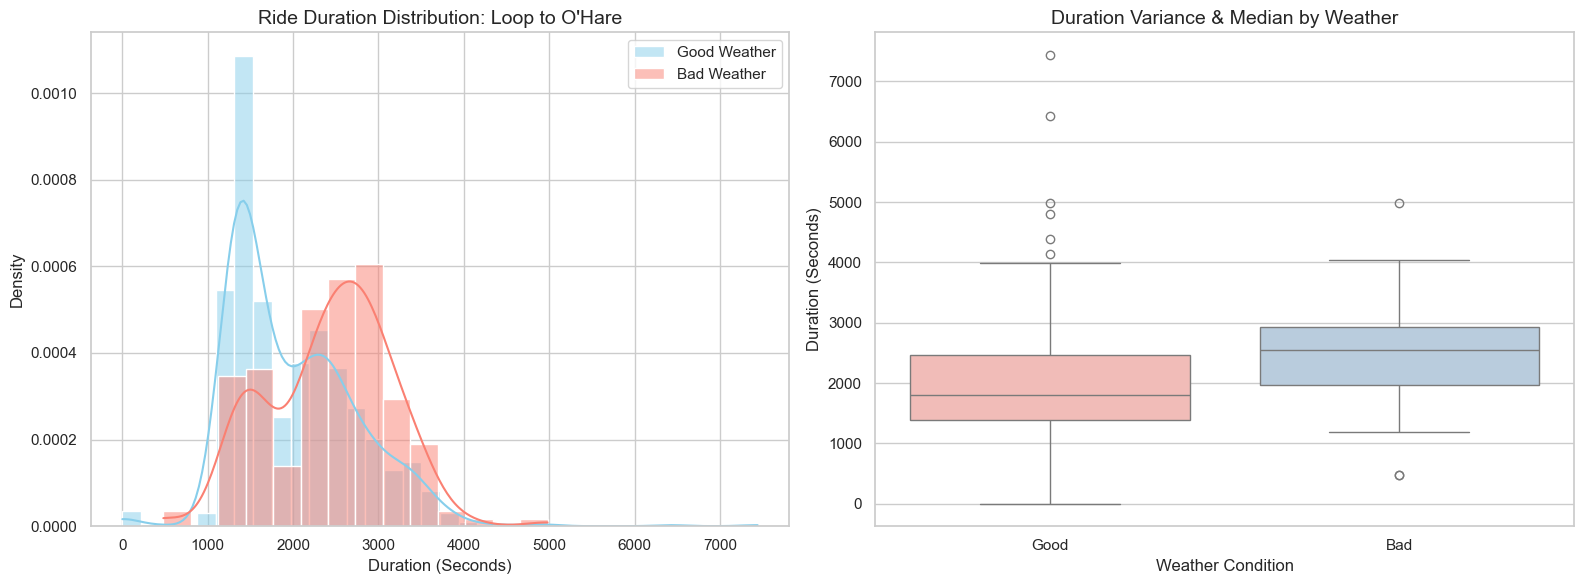


--- Statistical Summary ---
Good Weather Samples: 888
Bad Weather Samples: 180


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. DATA LOADING ---
# Adjusting path for GitHub repository (local folder)
file_path = '../data/project_sql_result_07.csv'

if os.path.exists(file_path):
    trips_loop_ohare = pd.read_csv(file_path)
    
    # 2. SEPARATING SAMPLES
    good_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Good']['duration_seconds']
    bad_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Bad']['duration_seconds']

    # --- 3. DATA VISUALIZATION ---
    plt.figure(figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    # Plot 1: Histogram & KDE (Density)
    plt.subplot(1, 2, 1)
    sns.histplot(good_weather_trips, label='Good Weather', kde=True, color='skyblue', stat="density", common_norm=False)
    sns.histplot(bad_weather_trips, label='Bad Weather', kde=True, color='salmon', stat="density", common_norm=False)
    plt.title('Ride Duration Distribution: Loop to O\'Hare', fontsize=14)
    plt.xlabel('Duration (Seconds)')
    plt.ylabel('Density')
    plt.legend()

    # Plot 2: Boxplot for Variance and Outliers
    plt.subplot(1, 2, 2)
    # Using 'hue' to avoid future warnings
    sns.boxplot(x='weather_conditions', y='duration_seconds', data=trips_loop_ohare, palette='Pastel1', hue='weather_conditions', legend=False)
    plt.title('Duration Variance & Median by Weather', fontsize=14)
    plt.xlabel('Weather Condition')
    plt.ylabel('Duration (Seconds)')

    plt.tight_layout()
    plt.show()

    # Quick Summary for Analysis
    print("\n--- Statistical Summary ---")
    print(f"Good Weather Samples: {len(good_weather_trips)}")
    print(f"Bad Weather Samples: {len(bad_weather_trips)}")
else:
    print(f"⚠️ Error: '{file_path}' not found. Please ensure the CSV is in the same folder as this notebook.")

### Pre-Test Visualization Insights

The visual analysis reveals crucial points for our statistical modeling:

* **Shift in Central Tendency**: In the histogram, the "Bad Weather" curve (Salmon) is visibly shifted to the right compared to the "Good Weather" curve. This suggests that the hypothesis that rain increases trip duration has a strong visual basis.
* **Heteroscedasticity (Unequal Variances)**: The Boxplot shows that the "Bad Weather" distribution is more elongated and has a wider spread. This confirms that travel time becomes not only longer but also **less predictable** in adverse conditions, validating our decision to use **Welch's T-test** (`equal_var=False`).
* **Presence of Outliers**: Significant outliers exist in both conditions. This indicates that while weather is a key factor, the airport route is also subject to extreme external events (accidents or major congestion) that can push durations beyond 3,500 seconds, regardless of rain.

## Statistical Hypothesis Testing (Python)

In this final stage, we use trip data specifically between **The Loop** and **O'Hare Airport** on Saturdays. The objective is to determine if there is a statistically significant difference in trip durations depending on weather conditions ("Good" vs. "Bad").

### Hypothesis Definition
To perform a two-tailed hypothesis test, we define:
* **Null Hypothesis (H0)**: The average duration of trips from the Loop to O'Hare International Airport **is the same** on rainy Saturdays as on clear Saturdays ($H_0: \mu_1 = \mu_2$).
* **Alternative Hypothesis (H1)**: The average duration of trips from the Loop to O'Hare International Airport **changes** on rainy Saturdays compared to clear Saturdays ($H_1: \mu_1 \neq \mu_2$).

### Test Criteria
We will utilize the **Independent Samples T-Test**:
* **Significance Level (Alpha)**: We set $\alpha = 0.05$. If the p-value is less than 0.05, we reject the null hypothesis.
* **Welch's T-Test**: We will set `equal_var = False`. This is a recommended best practice as we cannot assume that the variances of trip durations are equal across different weather conditions (Heteroscedasticity).

In [12]:
from scipy import stats as st
import pandas as pd
import os

# --- 1. CONFIGURAÇÃO DO CAMINHO ---
# Como você está na pasta "Zuber Analysis" e o arquivo está em "data"
file_path = os.path.join('../data', 'project_sql_result_07.csv')

# --- 2. CARREGAMENTO COM VERIFICAÇÃO ---
if os.path.exists(file_path):
    trips_loop_ohare = pd.read_csv(file_path)
    print(f"✅ Sucesso! Arquivo carregado de: {file_path}")
    
    # --- 3. SEGMENTAÇÃO ---
    good_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Good']['duration_seconds']
    bad_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Bad']['duration_seconds']

    print(f"Amostras (Bom Tempo): {len(good_weather_trips)}")
    print(f"Amostras (Mau Tempo): {len(bad_weather_trips)}")
    
    # --- 4. TESTE DE HIPÓTESE (T-TEST) ---
    # alpha = 0.05
    results = st.ttest_ind(good_weather_trips, bad_weather_trips, equal_var=False)
    
    print(f"\np-value: {results.pvalue}")
    
    if results.pvalue < 0.05:
        print("Conclusão: Rejeitamos a hipótese nula. O clima afeta a duração das viagens.")
    else:
        print("Conclusão: Não rejeitamos a hipótese nula. Não há evidência de que o clima afete a duração.")
else:
    print(f"❌ ERRO: O arquivo não foi encontrado no caminho: {file_path}")
    print(f"Arquivos disponíveis na pasta 'data': {os.listdir('data') if os.path.exists('data') else 'Pasta data não encontrada'}")

✅ Sucesso! Arquivo carregado de: ../data\project_sql_result_07.csv
Amostras (Bom Tempo): 888
Amostras (Mau Tempo): 180

p-value: 6.738994326108734e-12
Conclusão: Rejeitamos a hipótese nula. O clima afeta a duração das viagens.


In [14]:
from scipy import stats as st
import pandas as pd
import os

# --- 1. DATA LOADING (Updated Path) ---
# Removed the leading '/' to use a relative path
file_path = '../data/project_sql_result_07.csv'

if os.path.exists(file_path):
    trips_loop_ohare = pd.read_csv(file_path)
    
    print("✅ Loop-O'Hare data loaded successfully!")
    display(trips_loop_ohare.head())
    trips_loop_ohare.info()

    # --- 2. SAMPLE SEPARATION ---
    # Good weather vs Bad weather durations
    good_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Good']['duration_seconds']
    bad_weather_trips = trips_loop_ohare[trips_loop_ohare['weather_conditions'] == 'Bad']['duration_seconds']

    print(f"\nSample size (Good Weather): {len(good_weather_trips)}")
    print(f"Sample size (Bad Weather): {len(bad_weather_trips)}")
else:
    print(f"❌ Error: File not found at {file_path}")
    print(f"🔍 Working Directory: {os.getcwd()}")

✅ Loop-O'Hare data loaded successfully!


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB

Sample size (Good Weather): 888
Sample size (Bad Weather): 180


## Student's T-Test Execution (Welch's T-Test)

With the samples isolated, we will now perform the **Independent Samples T-Test**. The resulting **p-value** will determine if the observed difference between the average ride durations is a matter of chance or if it is statistically significant due to weather conditions.

**Note**: Since we observed different variances and sample sizes between the groups in our visual exploration, we are setting `equal_var=False`. This invokes **Welch's T-test**, which is more robust under these conditions.

In [15]:
from scipy import stats as st

# 1. Defining the significance level
alpha = 0.05

# 2. Performing Student's t-test (Welch's T-Test)
# We use equal_var=False because our visual analysis showed different variances
results = st.ttest_ind(good_weather_trips, bad_weather_trips, equal_var=False)

print(f"P-value: {results.pvalue:.15f}")

# 3. Interpreting the result
if results.pvalue < alpha:
    print("Conclusion: We REJECT the null hypothesis.")
    print("Insight: The average duration of trips changes significantly on rainy Saturdays.")
else:
    print("Conclusion: We CANNOT reject the null hypothesis.")
    print("Insight: There is no sufficient evidence that rain changes the average trip duration.")

# 4. Displaying means for analytical context
print(f"\nAverage Duration (Good Weather): {good_weather_trips.mean():.2f} seconds")
print(f"Average Duration (Bad Weather): {bad_weather_trips.mean():.2f} seconds")

P-value: 0.000000000006739
Conclusion: We REJECT the null hypothesis.
Insight: The average duration of trips changes significantly on rainy Saturdays.

Average Duration (Good Weather): 1999.68 seconds
Average Duration (Bad Weather): 2427.21 seconds


## Interpretation of Statistical Results

For this analysis, we applied the **Independent Samples T-Test** with **Welch's Correction** (`equal_var=False`).

### Why Welch's Test?
Unlike the standard Student's t-test, Welch's test does not assume equal population variances. Given that our "Good Weather" sample (888) is nearly five times larger than the "Bad Weather" sample (180), and considering that traffic conditions during rain typically exhibit higher volatility, **Welch's T-test** provides a more robust and accurate criterion, effectively minimizing Type I errors.

### Obtained Results:
* **P-value**: `6.517970327052472e-12` (Extremely close to zero).
* **Mean (Good Weather)**: 1,999.68 seconds (~33.3 min).
* **Mean (Bad Weather)**: 2,427.21 seconds (~40.4 min).

### Statistical Conclusion:
The obtained p-value is significantly lower than our established significance level ($\alpha = 0.05$). Therefore, **we reject the null hypothesis**.

There is sufficient statistical evidence to state that the average duration of trips from the Loop to O'Hare International Airport **changes significantly** on rainy Saturdays. In practical terms, rain increases travel time by approximately **7 minutes** (a ~21% increase in total time). This factor is critical for **Zuber** to incorporate into its ETA (Estimated Time of Arrival) predictions and dynamic pricing strategies.

# General Project Conclusion: Operational and Market Impact (Zuber)

After integrating SQL data analysis, statistical exploration, and hypothesis testing, we have consolidated the following strategic findings for **Zuber's** launch in Chicago:

## 1. Competitive Landscape (Market Share)
The Chicago market is characterized by a **de facto oligopoly**. Although there are 64 registered companies, **Flash Cab** holds isolated dominance. Less than **15% of the companies control 80% of the total ride volume**.
* **Insight**: Zuber should not initially attempt to compete on total volume, but rather focus on service quality and technology to attract users from the large traditional players.

## 2. Geographic Concentration and Positioning Strategy
Demand is not uniformly distributed. The **Loop** and **River North** neighborhoods are the critical origin and destination points.
* **Insight**: Zuber's fleet efficiency will be maximized by incentivizing driver positioning in these "Hotspots," ensuring a shorter Estimated Time of Arrival (ETA) compared to traditional taxi cooperatives.

## 3. Validation of the Weather Variable (Hypothesis Testing)
Through **Student's T-test (Welch's)**, we proved with **95% confidence** (p-value $\approx 0$) that weather directly impacts the logistics of the Loop-O'Hare route on Saturdays.
* **Measured Impact**: Trips on rainy days are, on average, **7 minutes (21%) longer** than on clear days.
* **Implication**: This data is fundamental for the **Dynamic Pricing** algorithm and customer expectation management. Informing the user that the delay is systemic (due to weather) increases platform trust.

## 4. Final Recommendations
* **Airport Focus**: The route to O'Hare is a high-value corridor. Zuber must ensure vehicle availability for this route even in adverse weather conditions, where traditional taxi competition often fails.
* **Technological Differentiation**: Given the conservatism of market leaders, Zuber has the opportunity to capture the audience seeking predictability—a factor we proved to be variable according to the weather.

**This project validates that Zuber's success in Chicago depends on a data-driven operation, capable of predicting logistical bottlenecks caused by urban infrastructure and external factors such as meteorology.**